# Python based modelling of NMOS I-V characteristics linked to Semiconductor Process Parameters

## Code by $\text{Ronit Dutta (1010683)}$ 

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# OBJECTIVE

To **establish a quantitative, predictive computational model** for the NMOSFET, directly linking fundamental semiconductor **fabrication parameters** (oxide thickness/dielectric constant, substrate doping concentration, and interface trap charge) to the resultant **electrical performance metrics** ($C_{ox}$, $V_{th}$, and $I_D$), thereby illustrating the critical relationships that govern device behavior and variability in nanoscale technologies.

## Experiment Matrix:

| Factor | Levels (examples) | Notes |
| :--- | :--- | :--- |
| $t_{ox}$ | 0.8, 1.2, 1.6, 2.4 nm | Ellipsometry link $\rightarrow C_{ox}$ |
| $\kappa$ | 3.9 (SiO$_2$), 7 (Si$_3$N$_4$), 20 (HfO$_2$) | Material choice |
| $N_A$ | $1 \times 10^{16}$, $1 \times 10^{21}$ m$^{-3}$ | SIMS link |
| $Q_{it}$ | 0, $2 \times 10^{-3}$, $5 \times 10^{-3}$ C/m$^2$ | Interface traps/AFM context |
| $\phi_{MS}$ | $-0.2$, 0.0, $+0.2$ V | Metal/work-function selection |
| $\mu_n$ | 0.02--0.06 m$^2$/Vs | Roughness, phonon scatter proxy |
| $\lambda$ | 0--0.05 V$^{-1}$ | CLM for output resistance |

## Step 1 : OXIDE CAPACITANCE :-

$C_{ox} = \dfrac{\varepsilon_0 \varepsilon_r}{t_{ox}}$


Input parameters:
* Dielectric constant ($\varepsilon_r$) for $Si O_2$, $Si_3 N_4$, $Hf O_2$.
* Oxide thickness ($t_{ox}$) measured by Ellipsometry or XRR.

In [2]:
#input
e0 = 8.854187*1e-12 #epsilon0
er = [3.9,7,20]
tox = [np.linspace(0.8e-9, 3.0e-9, num=25), np.linspace(1e-9, 3.0e-9, num=25), np.linspace(0.5e-9, 2.0e-9, num=25)]
(er,tox)

([3.9, 7, 20],
 [array([8.00000000e-10, 8.91666667e-10, 9.83333333e-10, 1.07500000e-09,
         1.16666667e-09, 1.25833333e-09, 1.35000000e-09, 1.44166667e-09,
         1.53333333e-09, 1.62500000e-09, 1.71666667e-09, 1.80833333e-09,
         1.90000000e-09, 1.99166667e-09, 2.08333333e-09, 2.17500000e-09,
         2.26666667e-09, 2.35833333e-09, 2.45000000e-09, 2.54166667e-09,
         2.63333333e-09, 2.72500000e-09, 2.81666667e-09, 2.90833333e-09,
         3.00000000e-09]),
  array([1.00000000e-09, 1.08333333e-09, 1.16666667e-09, 1.25000000e-09,
         1.33333333e-09, 1.41666667e-09, 1.50000000e-09, 1.58333333e-09,
         1.66666667e-09, 1.75000000e-09, 1.83333333e-09, 1.91666667e-09,
         2.00000000e-09, 2.08333333e-09, 2.16666667e-09, 2.25000000e-09,
         2.33333333e-09, 2.41666667e-09, 2.50000000e-09, 2.58333333e-09,
         2.66666667e-09, 2.75000000e-09, 2.83333333e-09, 2.91666667e-09,
         3.00000000e-09]),
  array([5.0000e-10, 5.6250e-10, 6.2500e-10, 6.8750e-10

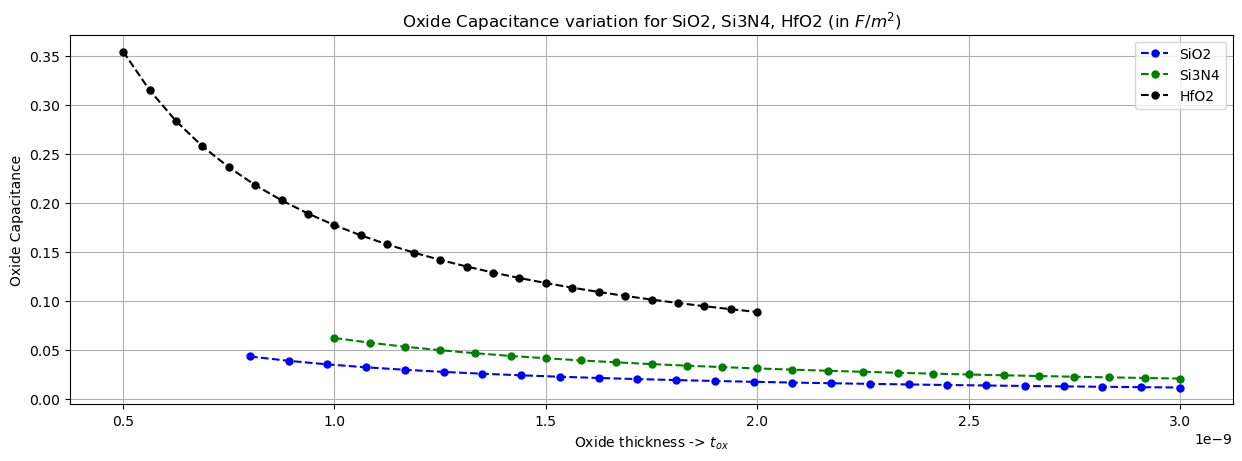

In [3]:
Cox1 = e0*er[0]/tox[0]
Cox2 = e0*er[1]/tox[1]
Cox3 = e0*er[2]/tox[2]

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
plt.plot(tox[0], Cox1, color='b', marker='.', ls='--', lw=1.5,markersize=10,label="SiO2")
plt.plot(tox[1], Cox2, color='g', marker='.', ls='--', lw=1.5,markersize=10,label="Si3N4")
plt.plot(tox[2], Cox3, color='k', marker='.', ls='--', lw=1.5,markersize=10,label="HfO2")
plt.title("Oxide Capacitance variation for SiO2, Si3N4, HfO2 (in $F/m^2$)")
plt.xlabel("Oxide thickness -> $t_{ox}$")
plt.ylabel('Oxide Capacitance')
plt.legend()
plt.show()

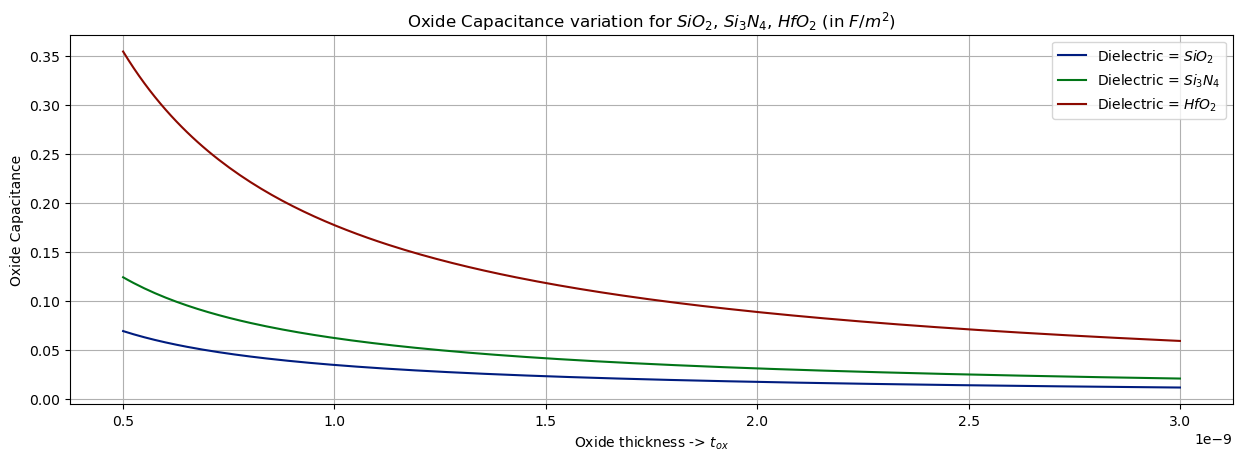

In [4]:
# ignoring the problem constraints and plotting the three plots simultaneously for a global min value of 0.5 and global max of 3.0
tox = np.linspace(0.5e-9, 3.0e-9,num=200)
Cox = []

for ers in er:
    cox = e0*ers/tox
    Cox.append(cox)

labels = ["$SiO_2$","$Si_3N_4$","$HfO_2$"]

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
for i in range(len(Cox)) :
    plt.plot(tox, Cox[i], label=f"Dielectric = {labels[i]}")

plt.title("Oxide Capacitance variation for $SiO_2$, $Si_3N_4$, $HfO_2$ (in $F/m^2$)")
plt.xlabel("Oxide thickness -> $t_{ox}$")
plt.ylabel('Oxide Capacitance')
plt.legend()
plt.show()

The family of curves for $C_{ox}$ increases with increase in $\epsilon_r$ and follows a general trend when $t_{ox}$ values are swept in a fixed range and satisfies $C_{ox} \propto \dfrac{1}{t_{ox}}$

## Step 2 : THRESHOLD VOLTAGE :-

$$V_{th} = \phi_{MS} - 2\phi_F - \dfrac{Q_{it}}{C_{\text{ox}}} + \gamma(N_A,C_{ox}) \left( \sqrt{2\phi_F + V_{SB}} - \sqrt{2\phi_F} \right)$$

$$\phi_F = \frac{kT}{q} \ln \left(\frac{N_A}{n_i}\right) = V_T \left( \ln (N_A) + 22.6203858218 \right) \text{ (where }V_T \text{ means thermal voltage )}$$ $$= 0.0259 \left( \ln (N_A) + 22.6203858218 \right)$$

$$\gamma = \frac{\sqrt{2 q \epsilon_{\text{Si}} N_A}}{C_{\text{ox}}} = 5.76 \times 10^{-16} \dfrac{\sqrt{N_A}}{C_{ox}}$$

Input parameters:
* $N_A$ (acceptor doping) from SIMS data
* $Q_{it}$ (interface charge) from AFM/defect density
* $\phi_{MS}$ (metal-semiconductor work function difference)
* $C_{ox}$ from Step 1


Python task: Compute $V_{th}$ variation with $N_A$, $t_{ox}$, and $Q_{it}$.


Plot: $V_T$ vs. $N_A$, $V_T$ vs. $t_{ox}$

In [28]:
phims = 0.1
#sweep variables
Cox = Cox[2]
Na = np.linspace(1e16,1e18,num=200)
qit = np.linspace(0,5e-8,num=200)
len(Cox)==len(Na)==len(qit)==len(tox) # sanity check

True

In [65]:
#static parameters prepared for sweep
Na_0 = 1e17
qit_0 = 5e-8
tox_0 = 0.8e-9
Cox_0 = float(np.mean(Cox[:20])) # taking the mean of the top 20 cox otherwise full mean will make cox too low and hence undesirable.
vth_0 = -1.0717 - qit_0/Cox_0 - 0.0518*np.log(Na_0)
(Na_0, qit_0, Cox_0, float(vth_0))

(1e+17, 5e-08, 0.2899305747440386, -3.099356605345635)

**Voltage labelling** =>

$$V_{th} = \underbrace{\left( \phi_{MS} - \dfrac{Q_{it}}{C_{\text{ox}}} \right)}_{V_{FB} \text{ (Flat Band Voltage)}} - \underbrace{2\phi_F}_{\text{Substrate Fermi potential}} + \underbrace{\gamma(N_A,C_{ox}) \left( \sqrt{2\phi_F + V_{SB}} - \sqrt{2\phi_F} \right)}_{\text{Body effect voltage}}$$

**Assumption** =>

We may take $V_{SB} = 0$ because the NMOS is grounded.

$$V_{th} = \underbrace{\left( \phi_{MS} - \dfrac{Q_{it}}{C_{\text{ox}}} \right)}_{V_{FB} \text{ (Flat Band Voltage)}} - \underbrace{2\phi_F}_{\text{Substrate Fermi potential}} + \underbrace{\gamma(N_A,C_{ox}) \left( \sqrt{2\phi_F} \right)}_{\text{Depletion charge at }V_{SB}=0}$$

$$V_{th} = \underbrace{\left( \phi_{MS} - \dfrac{Q_{it}}{C_{\text{ox}}} \right)}_{V_{FB} \text{ (Flat Band Voltage)}} - \underbrace{2 \times 25.9 \times 10^{-3} \left( \ln (N_A) + 22.6203858218 \right)}_{\text{Substrate Fermi potential}} + \underbrace{5.76 \times 10^{-16} \dfrac{\sqrt{N_A}}{C_{ox}} \times \sqrt{2 \times 25.9 \times 10^{-3} \left( \ln (N_A) + 22.6203858218 \right)}}_{\text{Depletion Voltage}}$$

**Final Equation** (ready for analysis with only the sweep variables) :

$$V_{th} = \underbrace{\left(0.1 - \dfrac{Q_{it}}{C_{\text{ox}}} \right)}_{V_{FB} \text{ (Flat Band Voltage)}} - \underbrace{0.0518 \times \ln (N_A) - 1.1717}_{\text{Substrate Fermi potential}} + \underbrace{5.76 \times 10^{-16} \dfrac{\sqrt{N_A}}{C_{ox}} \times \sqrt{0.0518 \times \ln (N_A) - 1.1717}}_{\text{Depletion voltage}}$$

**Ready to use equation :**

$$V_{th} = -1.0717 - \dfrac{Q_{it}}{C_{\text{ox}}} - 0.0518 \times \ln (N_A) + 5.76 \times 10^{-16} \dfrac{\sqrt{N_A(0.0518 \times \ln{N_A} - 1.1717)}}{C_{ox}}$$

**Sweep variables =>**
* Analysis 1 : $Q_{it}$ will be sweeped when $C_{ox0}$ and $N_{A0}$ will be kept constant.
* Analysis 2 : $C_{ox}$ will be sweeped when $Q_{it0}$ and $N_{A0}$ will be kept constant.
* Analysis 3 : $N_{A}$ will be sweeped when $Q_{it0}$ and $C_{ox0}$ will be kept constant.

#### Analysis 1 : qit sweep

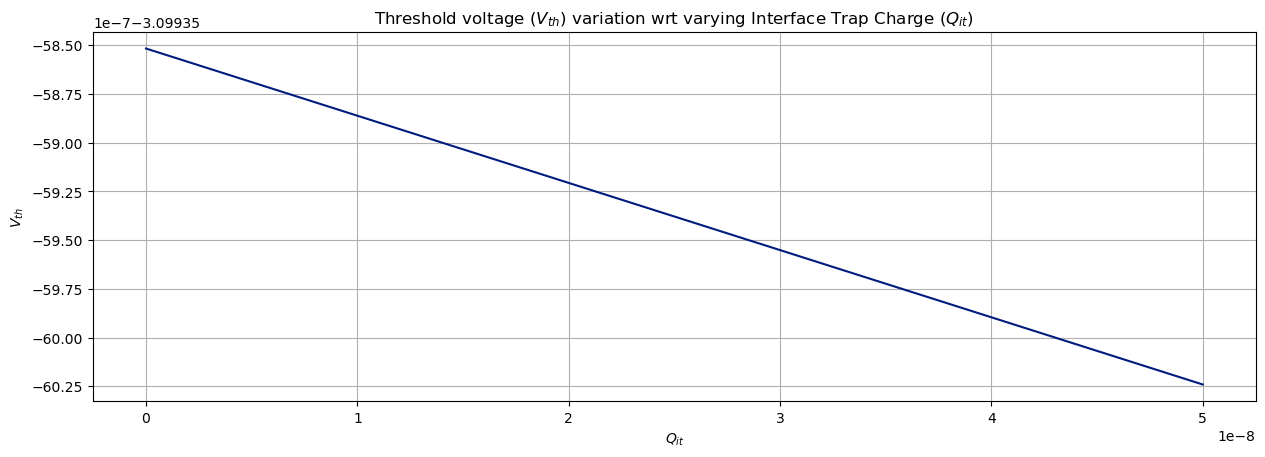

In [47]:
vth1 = -1.0717 - qit/Cox_0 - 0.0518*np.log(Na_0) + 5.76e-16*np.sqrt(Na_0*(0.0518*np.log(Na_0)-1.1717))/Cox_0

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
plt.plot(qit, vth1)
plt.title("Threshold voltage ($V_{th}$) variation wrt varying Interface Trap Charge $(Q_{it})$")
plt.xlabel("$Q_{it}$")
plt.ylabel("$V_{th}$")
plt.show()

#### Analysis 2 : Cox sweep

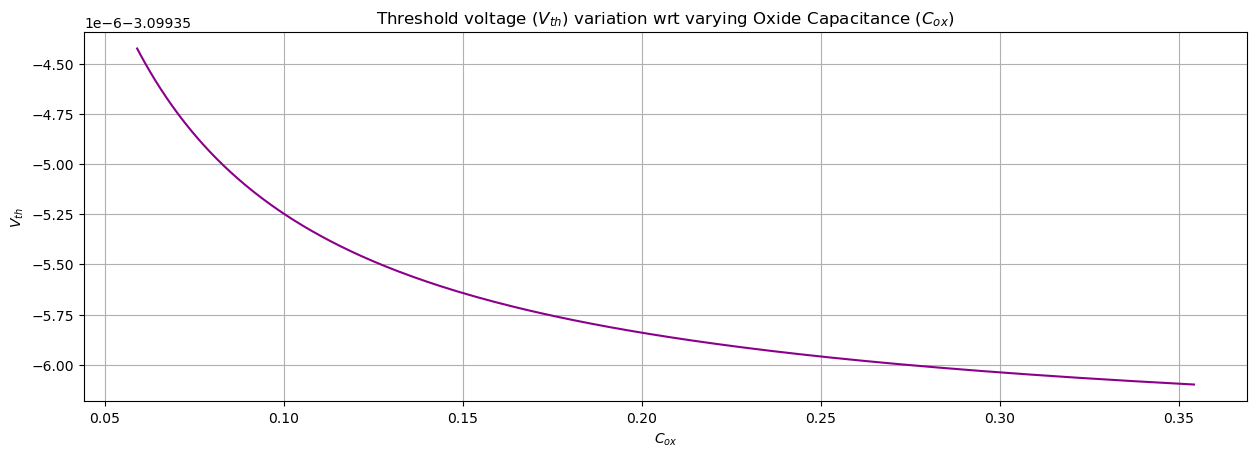

In [8]:
vth2 = -1.0717 - qit_0/Cox - 0.0518*np.log(Na_0) + 5.76e-16*np.sqrt(Na_0*(0.0518*np.log(Na_0)-1.1717))/Cox

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
plt.plot(Cox, vth2, color="darkmagenta")
plt.title("Threshold voltage ($V_{th}$) variation wrt varying Oxide Capacitance $(C_{ox})$")
plt.xlabel("$C_{ox}$")
plt.ylabel("$V_{th}$")
plt.show()

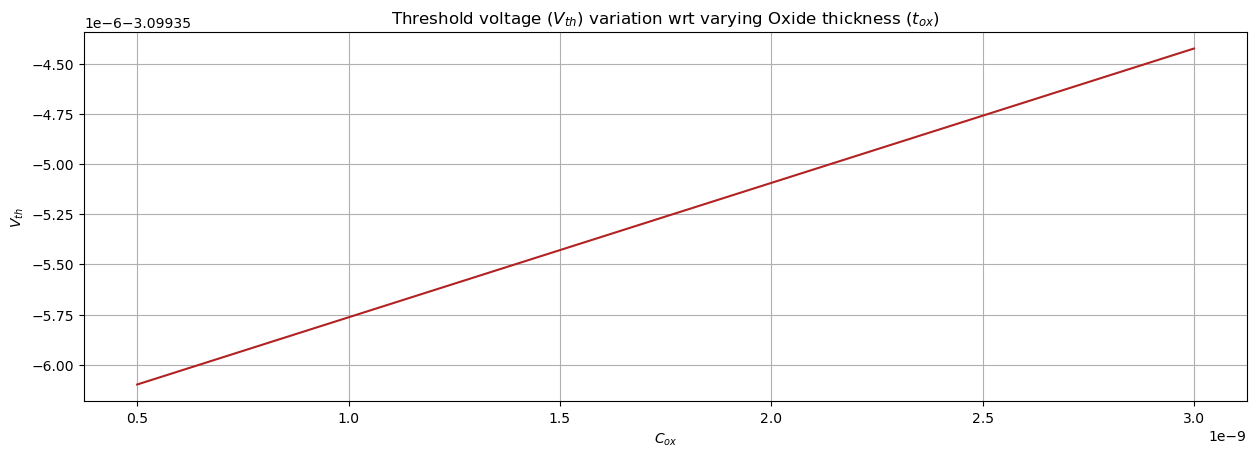

In [11]:
# tox sweep
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
plt.plot(tox, vth2,c="firebrick")
plt.title("Threshold voltage ($V_{th}$) variation wrt varying Oxide thickness $(t_{ox})$")
plt.xlabel("$C_{ox}$")
plt.ylabel("$V_{th}$")
plt.show()

#### Analysis 3 : $N_A$ sweep

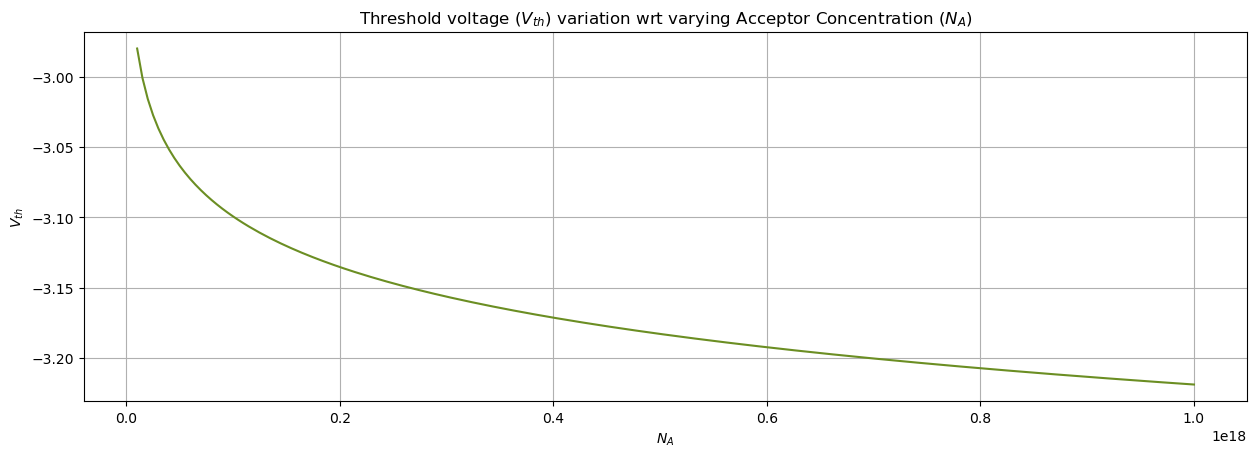

In [21]:
vth3 = -1.0717 - qit_0/Cox_0 - 0.0518*np.log(Na) + 5.76e-16*np.sqrt(Na*(0.0518*np.log(Na)-1.1717))/Cox_0

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
plt.plot(Na, vth3, c='olivedrab')
plt.title("Threshold voltage ($V_{th}$) variation wrt varying Acceptor Concentration $(N_{A})$")
plt.xlabel("$N_{A}$")
plt.ylabel("$V_{th}$")
plt.show()

## Step 3 : DRAIN CURRENT :-

Linear region :
$$I_D = \mu_n C_{\text{ox}} \dfrac{W}{L} \left[(V_{GS}-V_T) V_{DS} - \dfrac{V_{DS}^2}{2}\right]$$ which happens when $V_D < V_G - V_T$

Saturation region :
$$I_D = \mu_n C_{\text{ox}} \dfrac{W}{L} \left( V_{GS}-V_T \right)^2 \left( 1 + \lambda V_{DS} \right)$$ which happens when $V_D > V_G - V_T$

**Const variables** :-
* $\mu_n = 450 cm^2/Vs$
* $W/L = 10$


**Sweep variables (direct correlation - type 1)** -> *Analysis type 1*
* Sweep $V_G$ with constant $V_D$
* Sweep $V_D$ with constant $V_G$


(during type 1 analysis we need a $v_{th0}$ and a $C_{ox0}$ value).

**Sweep variables (family of curves correlation - type 2)** (random selection) -> *Analysis type 2*
* During each sweep first do an independent sweep, then randomly select 10 different $V_T$ and plot 10 with the same sweep vectors of $V_G$ or $V_D$
* After previous step, now randomly select 10 different $C_{ox}$ and plot 10 with the same sweep vectors of $V_G$ or $V_D$

Constant val $\left( \mu_n \dfrac{W}{L} \right)$ = 450*10 = 4500

Let's call this constant value $\beta$ !

Therefore our equations : 

1. Linear region - $$I_{DLin} = \beta C_{ox} \left[ (V_G - V_T)V_D - \dfrac{V_D^2}{2} \right]$$$$V_D < V_G - V_T$$
2. Saturation region - $$I_{DSat} = \beta C_{ox} (V_G - V_T)^2 \left( 1 + \lambda V_D \right)$$$$V_D > V_G - V_T$$


##### Ingredients we will need :

1. $V_T$ values => 5
2. $C_{ox}$ values => 5
3. $\beta$, $\lambda$ -> fixed consts.
4. $V_G$ sweep.
5. $V_D$ sweep.

In [15]:
# ingredients
beta = 4500e-4
lam = 0.015
vth_vals = np.linspace(0.2, 0.7, 5)
Cox_vals = np.sort(Cox[:5])
vth_vals,Cox_vals

(array([0.2  , 0.325, 0.45 , 0.575, 0.7  ]),
 array([0.32182342, 0.32934266, 0.33722167, 0.3454869 , 0.35416748]))

In [16]:
VGS_sweep = np.linspace(0, 5.0, 400)
VDS_sweep = np.linspace(0, 10.0, 400)

#### **NMOS Current Model** [MOST IMPORTANT]

In [17]:
def ID_linear(Cox, Vth, VGS, VDS):
    return beta * Cox * ( (VGS - Vth)*VDS - 0.5*(VDS**2) )

def ID_saturation(Cox, Vth, VGS, VDS):
    return 0.5 * beta * Cox * (VGS - Vth)**2 * (1 + lam * VDS)

def ID_total(Cox, Vth, VGS, VDS):
    """
    Strict separation:
    - If VDS < VGS - Vth -> linear formula only
    - If VDS >= VGS - Vth -> saturation formula only
    - If VGS < Vth -> transistor OFF
    """
    Vov = VGS - Vth
    VDS_arr = np.array(VDS, ndmin=1) # checking if V_DS is float/ array (only required in code because i got an error, no theoretical interpretation)
    Id = np.zeros_like(VDS_arr)

    if Vov <= 0:
        return Id if np.ndim(VDS) else Id.item()

    linear_mask = VDS_arr < Vov
    sat_mask = ~linear_mask

    Id[linear_mask] = ID_linear(Cox, Vth, VGS, VDS_arr[linear_mask])
    Id[sat_mask] = ID_saturation(Cox, Vth, VGS, VDS_arr[sat_mask])

    Id[Id < 0] = 0
    return Id if np.ndim(VDS) else Id.item()

### ANALYSIS 1 : $V_G$ SWEEP, $V_D$ CONSTANT $(=1V)$

#### Analysis 1.1 : $V_G$ sweep with constant $V_D = 1V$ for different $V_{th}$ values

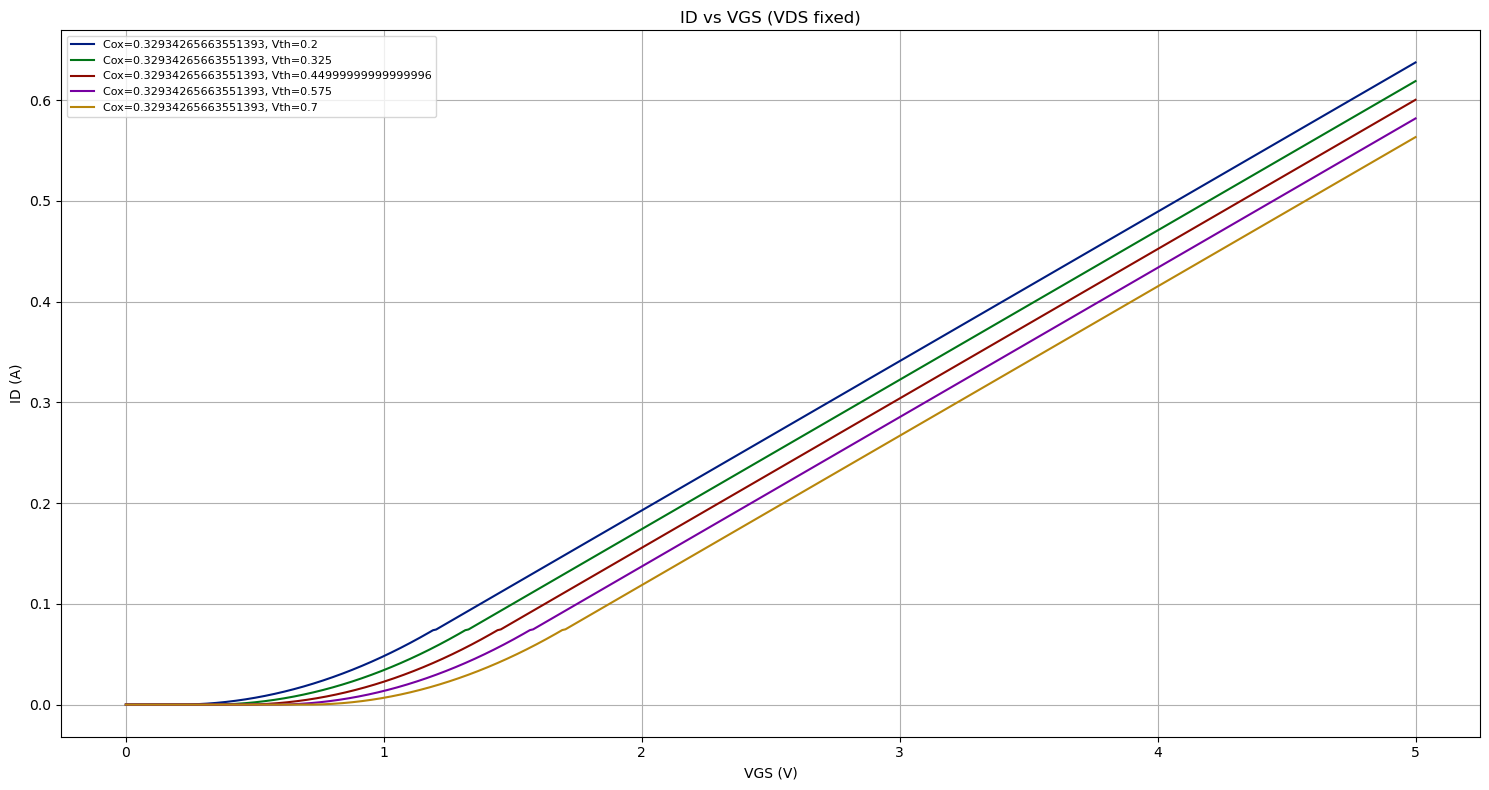

In [19]:
VDS_fixed = 1.0

plt.figure(figsize=(15, 8))
Cox_plot = np.random.choice(Cox_vals)
for Vth in vth_vals:
    IDs = np.array([
        ID_total(Cox_plot, Vth, VGS, VDS_fixed)
        for VGS in VGS_sweep
    ])
    label_text = f"Cox={Cox_plot}, Vth={Vth}"
    plt.plot(VGS_sweep, IDs, label=label_text)

plt.title("ID vs VGS (VDS fixed)")
plt.xlabel("VGS (V)")
plt.ylabel("ID (A)")
plt.grid()
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Analysis 1.2 : $V_G$ sweep with constant $V_D = 1V$ for different $C_{ox}$ values

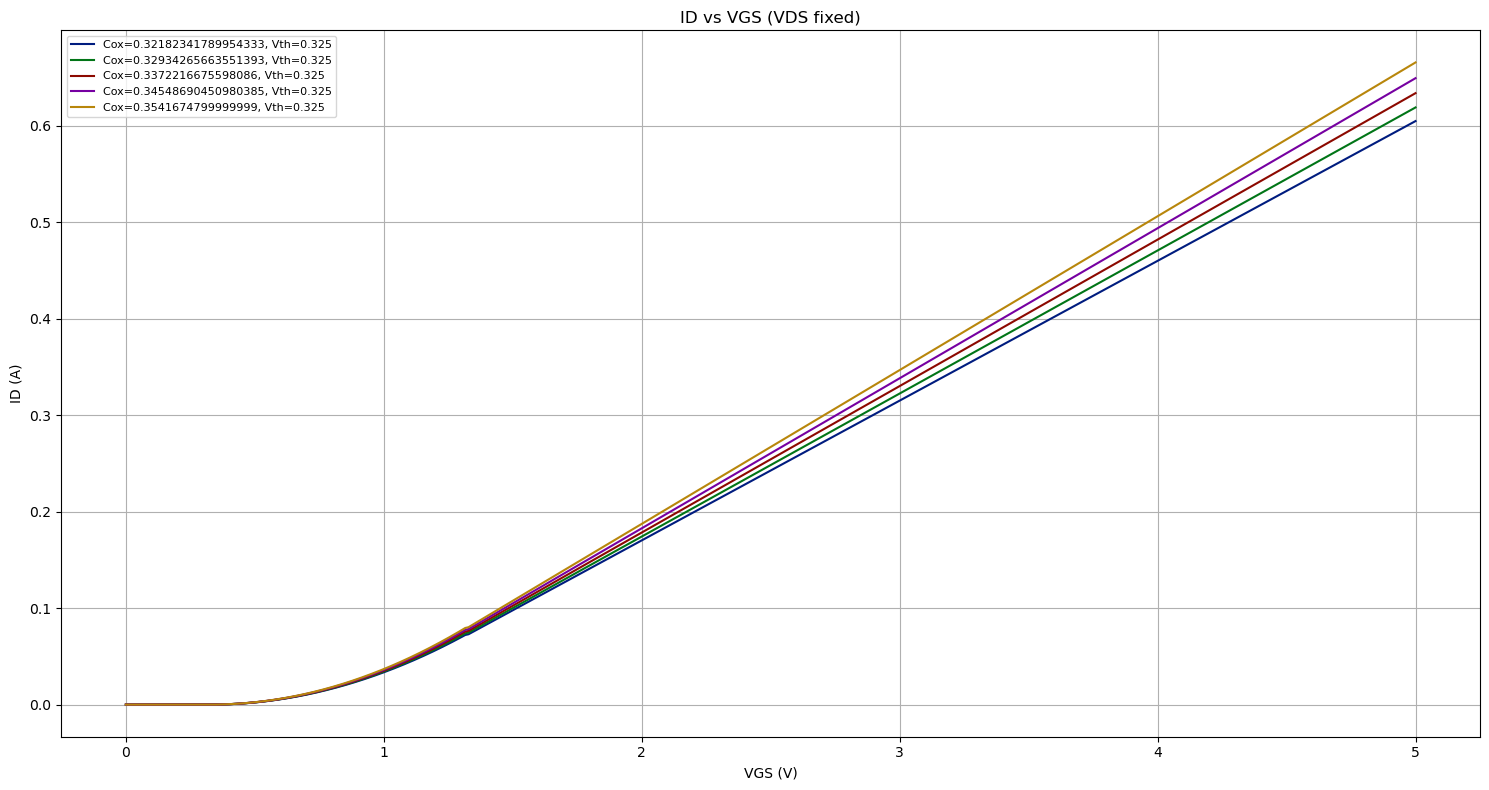

In [20]:
plt.figure(figsize=(15, 8))
Vth_plot = np.random.choice(vth_vals)

for Cox in Cox_vals:
    IDs = np.array([
        ID_total(Cox, Vth_plot, VGS, VDS_fixed)
        for VGS in VGS_sweep
    ])
    label_text = f"Cox={Cox}, Vth={Vth_plot}"
    plt.plot(VGS_sweep, IDs, label=label_text)

plt.title("ID vs VGS (VDS fixed)")
plt.xlabel("VGS (V)")
plt.ylabel("ID (A)")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### ANALYSIS 2 : $V_D$ SWEEP, $V_G$ = [0.8, 1.0, 1.2]

#### Analysis 2.1 : $V_D$ sweep for different $V_G = [0.6, 0.8, 1.0, 1.2, 1.4]$ for fixed nominal $C_{ox}$ & $V_{th}$.

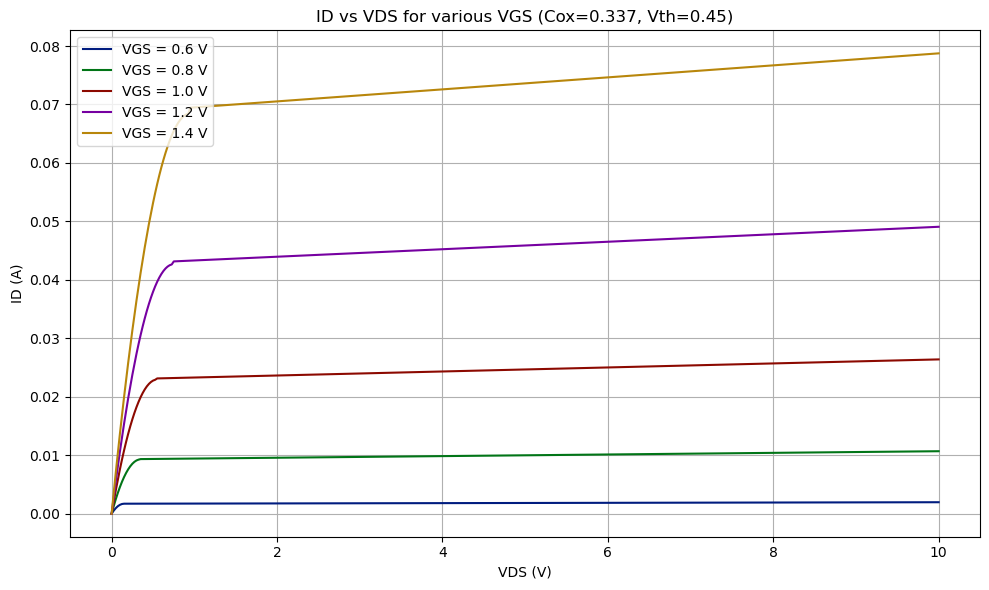

In [22]:
VGS_choices = [0.6, 0.8, 1.0, 1.2, 1.4] # assignment only recommends [0.8, 1.0, 1.2] but i took two extra values just like that

Cox_nom = Cox_vals[len(Cox_vals)//2]
Vth_nom = vth_vals[len(vth_vals)//2]

plt.figure(figsize=(10, 6))
for VGS in VGS_choices:
    IDs = ID_total(Cox_nom, Vth_nom, VGS, VDS_sweep)
    plt.plot(VDS_sweep, IDs, label=f"VGS = {VGS} V")

plt.title(f"ID vs VDS for various VGS (Cox={Cox_nom:.3g}, Vth={Vth_nom:.3g})")
plt.xlabel("VDS (V)")
plt.ylabel("ID (A)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Analysis 2.2 : $V_D$ sweep with fixed $V_G = 1.2V$ and for different $C_{ox}$ values

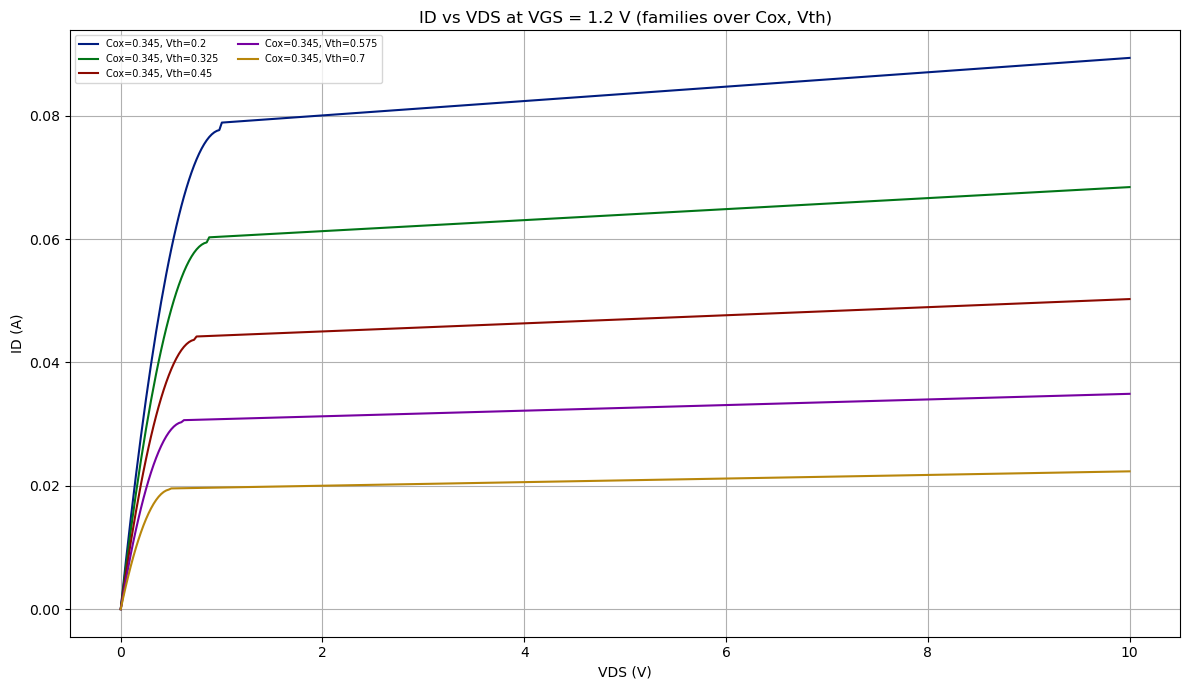

In [23]:
VGS_fixed = 1.2
Cox_plot = np.random.choice(Cox_vals)

plt.figure(figsize=(12, 7))
for Vth in vth_vals:
    IDs = ID_total(Cox_plot, Vth, VGS_fixed, VDS_sweep)
    label_text = f"Cox={Cox_plot:.3g}, Vth={Vth:.3g}"
    plt.plot(VDS_sweep, IDs, label=label_text)

plt.title(f"ID vs VDS at VGS = {VGS_fixed} V (families over Cox, Vth)")
plt.xlabel("VDS (V)")
plt.ylabel("ID (A)")
plt.grid(True)
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

#### Analysis 2.3 : $V_D$ sweep with fixed $V_G = 1.2V$ and for different $V_{th}$ values

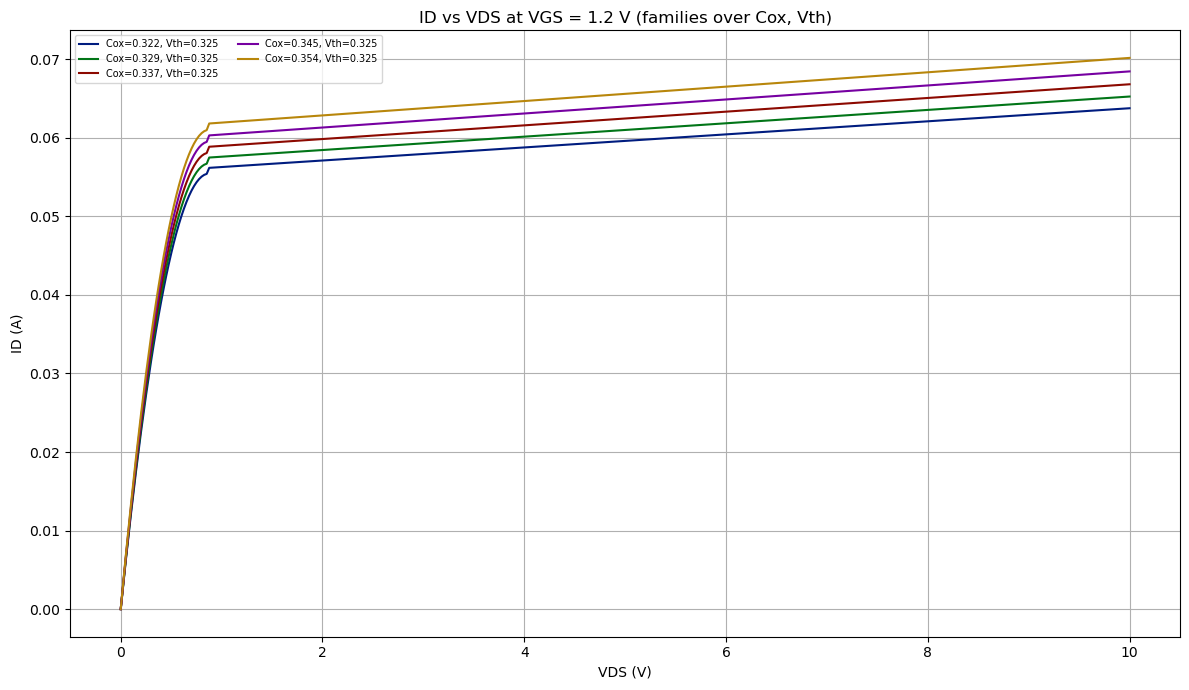

In [25]:
VGS_fixed = 1.2
Vth_plot = np.random.choice(vth_vals)

plt.figure(figsize=(12, 7))
for Cox in Cox_vals:
    IDs = ID_total(Cox, Vth_plot, VGS_fixed, VDS_sweep)
    label_text = f"Cox={Cox:.3g}, Vth={Vth_plot:.3g}"
    plt.plot(VDS_sweep, IDs, label=label_text)

plt.title(f"ID vs VDS at VGS = {VGS_fixed} V (families over Cox, Vth)")
plt.xlabel("VDS (V)")
plt.ylabel("ID (A)")
plt.grid(True)
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## STEP 4 : PROCESS PARAMETER SENSITIVITY

We go back to Step 2 for $V_T$ sensitivity. And to Step 3 for $I_{\text{D, sat}}$ sensitivity.

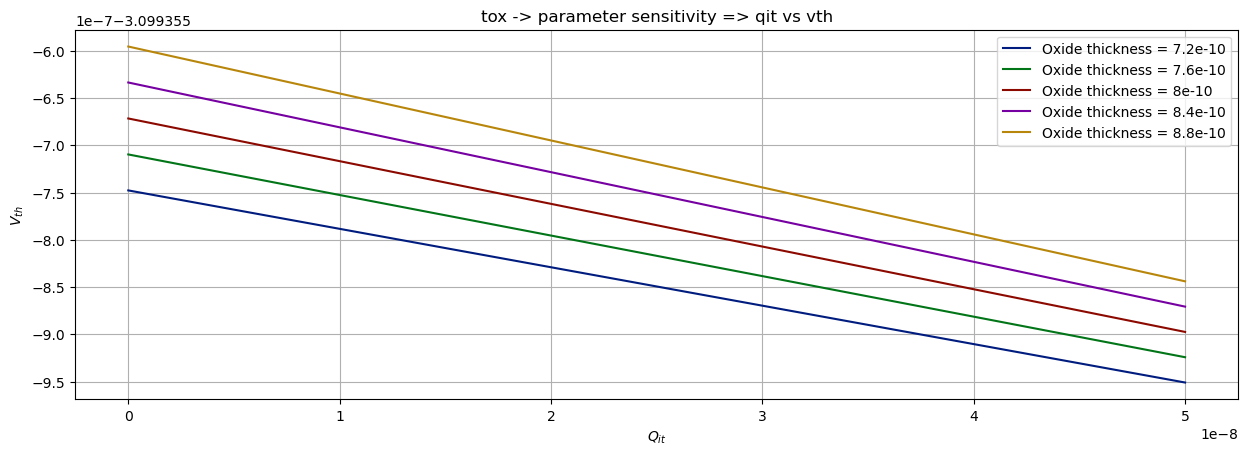

In [63]:
qit= qit
vth11 = []
tox_variation = list(np.linspace(0.9*tox_0,1.1*tox_0,num=5)) # +- 10% error sensitivity
for toxs in tox_variation:
    vth11.append(-1.0717 - qit/(e0*er[2]/toxs) - 0.0518*np.log(Na_0) + 5.76e-16*np.sqrt(Na_0*(0.0518*np.log(Na_0)-1.1717))/(e0*er[2]/toxs))

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
for i in range(len(vth11)):
    plt.plot(qit,vth11[i],label=f"Oxide thickness = {tox_variation[i]:.3g}")
plt.title("tox -> parameter sensitivity => qit vs vth")
plt.xlabel("$Q_{it}$")
plt.ylabel("$V_{th}$")
plt.legend()
plt.show()

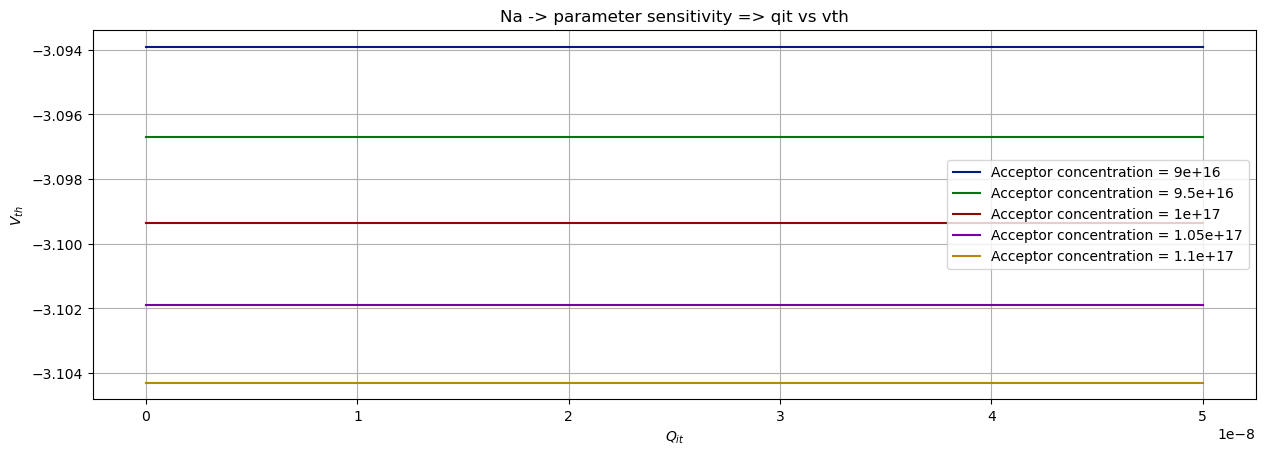

In [64]:
qit= qit
vth12 = []
Na_variation = list(np.linspace(0.9*Na_0,1.1*Na_0,num=5)) # +- 10% error sensitivity
for Nas in Na_variation:
    vth12.append(-1.0717 - qit/(e0*er[2]/tox_0) - 0.0518*np.log(Nas) + 5.76e-16*np.sqrt(Nas*(0.0518*np.log(Nas)-1.1717))/(e0*er[2]/tox_0))

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
for i in range(len(vth12)):
    plt.plot(qit,vth12[i],label=f"Acceptor concentration = {Na_variation[i]:.3g}")
plt.title("Na -> parameter sensitivity => qit vs vth")
plt.xlabel("$Q_{it}$")
plt.ylabel("$V_{th}$")
plt.legend()
plt.show()

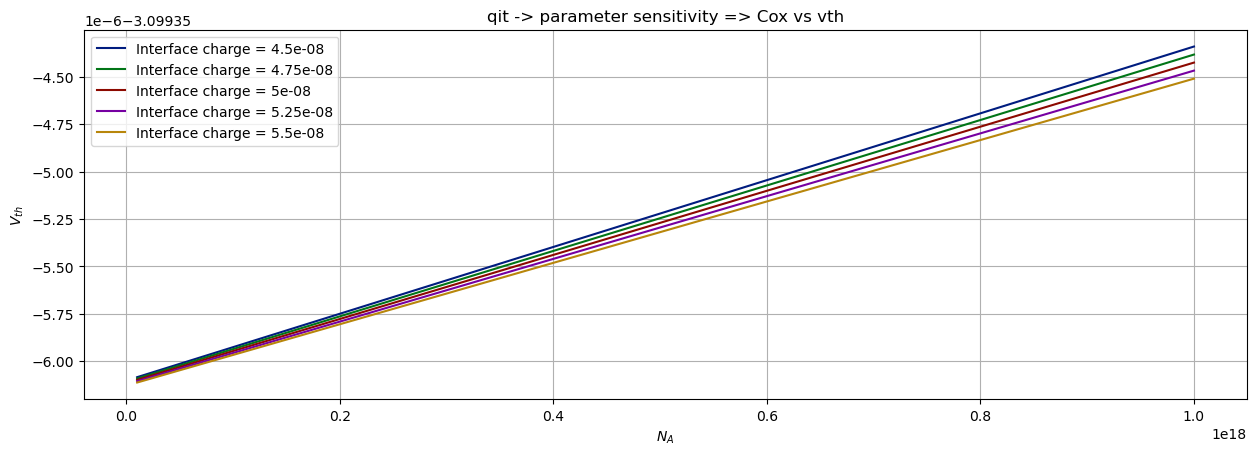

In [75]:
Cox = Cox
vth21 = []
qit_variation = list(np.linspace(0.9*qit_0,1.1*qit_0,num=5)) # +- 10% error sensitivity
for qits in qit_variation:
    vth21.append(-1.0717 - qits/Cox - 0.0518*np.log(Na_0) + 5.76e-16*np.sqrt(Na_0*(0.0518*np.log(Na_0)-1.1717))/Cox)

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
for i in range(len(vth21)):
    plt.plot(Na,vth21[i],label=f"Interface charge = {qit_variation[i]:.3g}")
plt.title("qit -> parameter sensitivity => Cox vs vth")
plt.xlabel("$N_{A}$")
plt.ylabel("$V_{th}$")
plt.legend()
plt.show()

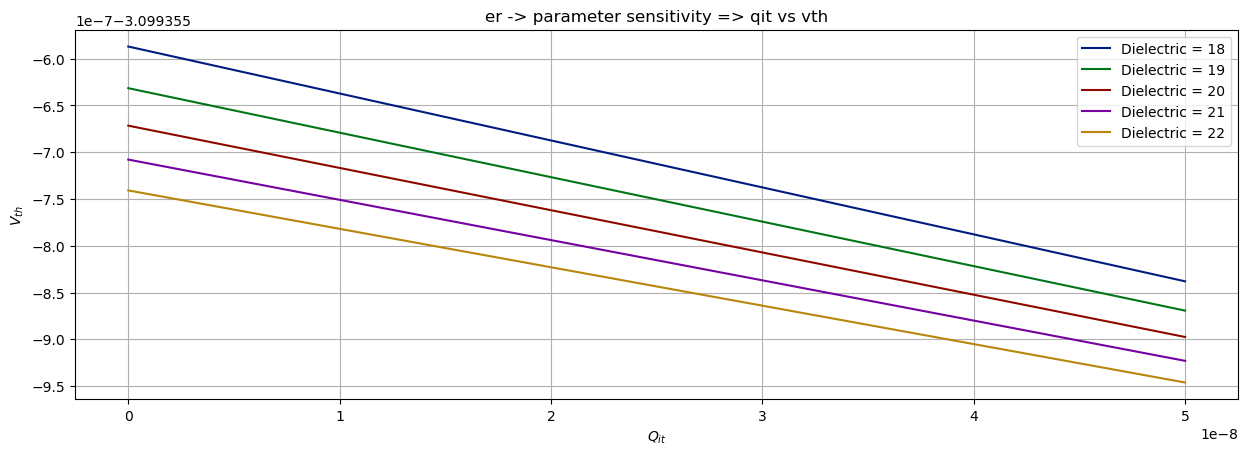

In [76]:
qit=qit
vth13 = []
er_variation = list(np.linspace(0.9*er[2],1.1*er[2],num=5)) # +- 10% error sensitivity
for ers in er_variation:
    vth13.append(-1.0717 - qit/(e0*ers/tox_0) - 0.0518*np.log(Na_0) + 5.76e-16*np.sqrt(Na_0*(0.0518*np.log(Na_0)-1.1717))/(e0*ers/tox_0))

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
for i in range(len(vth31)):
    plt.plot(qit,vth13[i],label=f"Dielectric = {er_variation[i]:.3g}")
plt.title("er -> parameter sensitivity => qit vs vth")
plt.xlabel("$Q_{it}$")
plt.ylabel("$V_{th}$")
plt.legend()
plt.show()

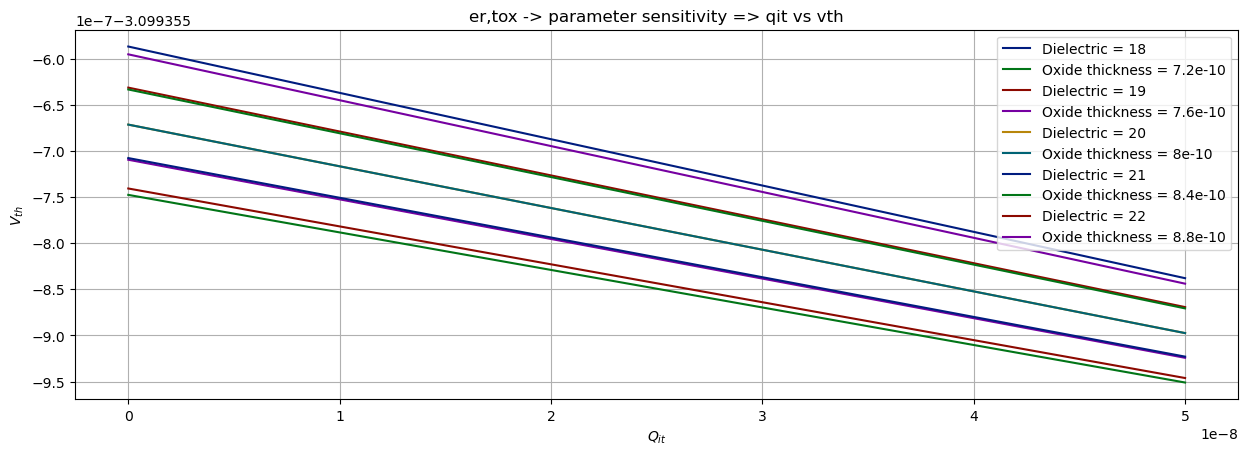

In [78]:
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure().set_figwidth(15)
plt.grid()
for i in range(len(vth31)):
    plt.plot(qit,vth13[i],label=f"Dielectric = {er_variation[i]:.3g}")
    plt.plot(qit,vth11[i],label=f"Oxide thickness = {tox_variation[i]:.3g}")
plt.title("er,tox -> parameter sensitivity => qit vs vth")
plt.xlabel("$Q_{it}$")
plt.ylabel("$V_{th}$")
plt.legend()
plt.show()

**ALL EXPECTED OBSERVATIONS ARE TRUE**

## STEP 5 : MONTE CARLO VARIATION

Vth: nominal = -3.8173 V, mean = -3.8174 V, sigma = 0.0052 V, yield(±5%) = 100.0%
Idsat: nominal = 1.357e+00 A, mean = 1.358e+00 A, sigma = 4.441e-02 A, yield(±5%) = 86.8%


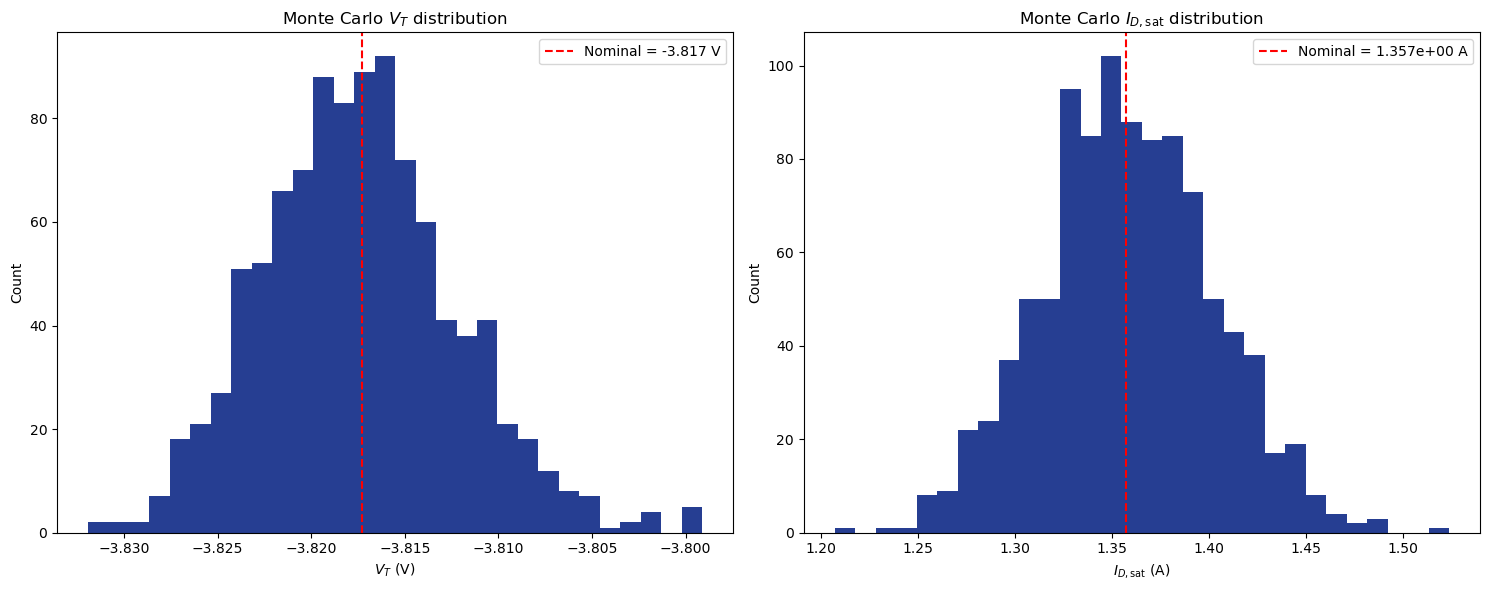

In [79]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

tox_mean = 1.5e-9
tox_sigma = 0.05e-9
Na_mean_cm = 1e17
Na_mean   = Na_mean_cm * 1e6
Na_sigma  = 0.10 * Na_mean
Qit_mean_cmc2 = 5e-8
Qit_mean = Qit_mean_cmc2 * 1e4
Qit_sigma = 0.20 * Qit_mean
er_ox = 20
beta = 4500e-4
lam  = 0.015
VGS_mc = 1.2
VDS_mc = 1.0
N_mc = 1000 # Number of Monte Carlo samples

# --- Sample process variations (Gaussian) ---
tox_mc  = np.random.normal(tox_mean,  tox_sigma,  size=N_mc)
Na_mc   = np.random.normal(Na_mean,   Na_sigma,   size=N_mc)
Qit_mc  = np.random.normal(Qit_mean,  Qit_sigma,  size=N_mc)

# oxide capacitance for each sample
Cox_mc = e0 * er_ox / tox_mc

# --- Vth model from your Step 2 (vectorized) ---
def Vth_from_params(Na, Qit, Cox):
    term_log = 0.0518 * np.log(Na)
    return -1.0717 - Qit/Cox - term_log + 5.76e-16 * np.sqrt(Na*(term_log - 1.1717)) / Cox

Vth_mc = Vth_from_params(Na_mc, Qit_mc, Cox_mc)

# nominal (no variation)
Cox_nom = e0 * er_ox / tox_mean
Vth_nom = Vth_from_params(Na_mean, Qit_mean, Cox_nom)

# --- Id,sat model from your Step 3 ---
def Idsat_from_params(VGS, VDS, Vth, Cox):
    Vov = VGS - Vth
    Id  = np.zeros_like(Vov)
    on  = Vov > 0
    Id[on] = beta * Cox[on] * (Vov[on]**2) * (1 + lam * VDS)
    return Id

Idsat_mc = Idsat_from_params(VGS_mc, VDS_mc, Vth_mc, Cox_mc)

Idsat_nom = Idsat_from_params(
    VGS_mc, VDS_mc,
    np.array([Vth_nom]),
    np.array([Cox_nom])
)[0]

# ---------------- Stats + Yield (±5% window) ----------------
Vth_mean = np.mean(Vth_mc)
Vth_std  = np.std(Vth_mc)

Ids_mean = np.mean(Idsat_mc)
Ids_std  = np.std(Idsat_mc)

Vth_tol  = 0.05 * abs(Vth_nom)
Ids_tol  = 0.05 * abs(Idsat_nom)

Vth_yield = np.mean(np.abs(Vth_mc - Vth_nom) <= Vth_tol)
Ids_yield = np.mean(np.abs(Idsat_mc - Idsat_nom) <= Ids_tol)

print(f"Vth: nominal = {Vth_nom:.4f} V, "
      f"mean = {Vth_mean:.4f} V, "
      f"sigma = {Vth_std:.4f} V, "
      f"yield(±5%) = {Vth_yield*100:.1f}%")

print(f"Idsat: nominal = {Idsat_nom:.3e} A, "
      f"mean = {Ids_mean:.3e} A, "
      f"sigma = {Ids_std:.3e} A, "
      f"yield(±5%) = {Ids_yield*100:.1f}%")

# ---------------- Histograms ----------------
plt.style.use("seaborn-v0_8-dark-palette")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(Vth_mc, bins=30, alpha=0.85)
ax1.axvline(Vth_nom, color="r", ls="--", label=f"Nominal = {Vth_nom:.3f} V")
ax1.set_title(r"Monte Carlo $V_T$ distribution")
ax1.set_xlabel(r"$V_T$ (V)")
ax1.set_ylabel("Count")
ax1.legend()

ax2.hist(Idsat_mc, bins=30, alpha=0.85)
ax2.axvline(Idsat_nom, color="r", ls="--", label=f"Nominal = {Idsat_nom:.3e} A")
ax2.set_title(r"Monte Carlo $I_{D,\mathrm{sat}}$ distribution")
ax2.set_xlabel(r"$I_{D,\mathrm{sat}}$ (A)")
ax2.set_ylabel("Count")
ax2.legend()

plt.tight_layout()
plt.show()